# Activity 2 - California Housing

**Yeo-Johnson transformations and Pearson correlation**

**Course:** Inteligencia Artificial y Aprendizaje
Automático - Tecnológico de Monterrey

**Student Name**: Carlos Rodrigo Salguero Alcántara

**ID**: A00833341

## 1.0 Notebook Configuration

In [150]:
from pathlib import Path
from typing import Final

In [151]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, power_transform

In [152]:
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

In [153]:
DATA_PATH: Final[Path] = Path("/content/sample_data/california_housing_train.csv")

In [154]:
TARGET: Final[str] = "median_house_value"
FEATURES: Final[list[str]] = [
    "longitude", "latitude", "housing_median_age", "total_rooms",
    "total_bedrooms", "population", "households", "median_income",
]

ALL_COLUMNS: Final[list[str]] = FEATURES + [TARGET]

In [155]:
YJ_COLUMNS: Final[list[str]] = [
    "total_rooms", "total_bedrooms", "population", "households", "median_income", TARGET,
]

YJ_SUFFIX: Final[str] = "_yj"
TARGET_YJ: Final[str] = TARGET + YJ_SUFFIX

## 2.0 Data Loading

In [156]:
def load_housing_data(path: Path) -> pd.DataFrame:
    """
    Read the CSV and check that all expected columns exist and are numeric.
    """

    if not path.is_file():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path)
    missing = [c for c in ALL_COLUMNS if c not in df.columns]

    if missing:
        raise ValueError(f"Missing columns: {missing}")
    non_numeric = [c for c in ALL_COLUMNS if not pd.api.types.is_numeric_dtype(df[c])]

    if non_numeric:
        raise ValueError(f"Non-numeric columns: {non_numeric}")

    return df

In [157]:
housing_df = load_housing_data(DATA_PATH)
print("Training set shape:", housing_df.shape)
housing_df.head()

Training set shape: (17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [158]:
housing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,17000.0,-119.562108,2.005166,-124.3500,-121.790000,-118.4900,-118.000,-114.3100
latitude,17000.0,35.625225,2.137340,32.5400,33.930000,34.2500,37.720,41.9500
housing_median_age,17000.0,28.589353,12.586937,1.0000,18.000000,29.0000,37.000,52.0000
total_rooms,17000.0,2643.664412,2179.947071,2.0000,1462.000000,2127.0000,3151.250,37937.0000
total_bedrooms,17000.0,539.410824,421.499452,1.0000,297.000000,434.0000,648.250,6445.0000
population,17000.0,1429.573941,1147.852959,3.0000,790.000000,1167.0000,1721.000,35682.0000
households,17000.0,501.221941,384.520841,1.0000,282.000000,409.0000,605.250,6082.0000
median_income,17000.0,3.883578,1.908157,0.4999,2.566375,3.5446,4.767,15.0001
median_house_value,17000.0,207300.912353,115983.764387,14999.0000,119400.000000,180400.0000,265000.000,500001.0000


## 3.0 Data Quality and Cleaning

In [159]:
def quality_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Per-column summary: missing values, distinct values and rows sitting at
    the column maximum.
    """

    return pd.DataFrame({
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
        "rows_at_max": (df == df.max()).sum(),
    })

In [160]:
print("Duplicated rows:", int(housing_df.duplicated().sum()))
quality_report(housing_df)

Duplicated rows: 0


,missing,missing_pct,n_unique,rows_at_max
longitude,0,0.0,827,1
latitude,0,0.0,840,2
housing_median_age,0,0.0,52,1052
total_rooms,0,0.0,5533,1
total_bedrooms,0,0.0,1848,1
population,0,0.0,3683,1
households,0,0.0,1740,1
median_income,0,0.0,11175,38
median_house_value,0,0.0,3694,814


In [161]:
def iqr_outlier_counts(df: pd.DataFrame, columns: list[str], k: float = 1.5) -> pd.Series:
    """
    Number of values outside the IQR fences (Q1 - k*IQR, Q3 + k*IQR) for each column.
    """

    counts = {}
    for col in columns:
        q1, q3 = df[col].quantile([0.25, 0.75])
        low, high = q1 - k * (q3 - q1), q3 + k * (q3 - q1)
        counts[col] = int(((df[col] < low) | (df[col] > high)).sum())

    return pd.Series(counts, name="iqr_outliers")

In [162]:
iqr_outlier_counts(housing_df, ALL_COLUMNS)

,iqr_outliers
longitude,0
latitude,0
housing_median_age,0
total_rooms,1076
total_bedrooms,1074
population,1015
households,1032
median_income,563
median_house_value,895


In [163]:
def plot_boxplots(df: pd.DataFrame, columns: list[str]) -> None:
    """
    One boxplot per column (each with its own scale) to spot outliers.
    """

    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.6 * n_rows))
    for ax, col in zip(axes.ravel(), columns):
        sns.boxplot(x=df[col], ax=ax, color="steelblue")
        ax.set_xlabel(col)

    for ax in axes.ravel()[len(columns):]:
        ax.set_visible(False)

    fig.suptitle("Boxplots of the original variables", y=1.0)
    fig.tight_layout()
    plt.show()

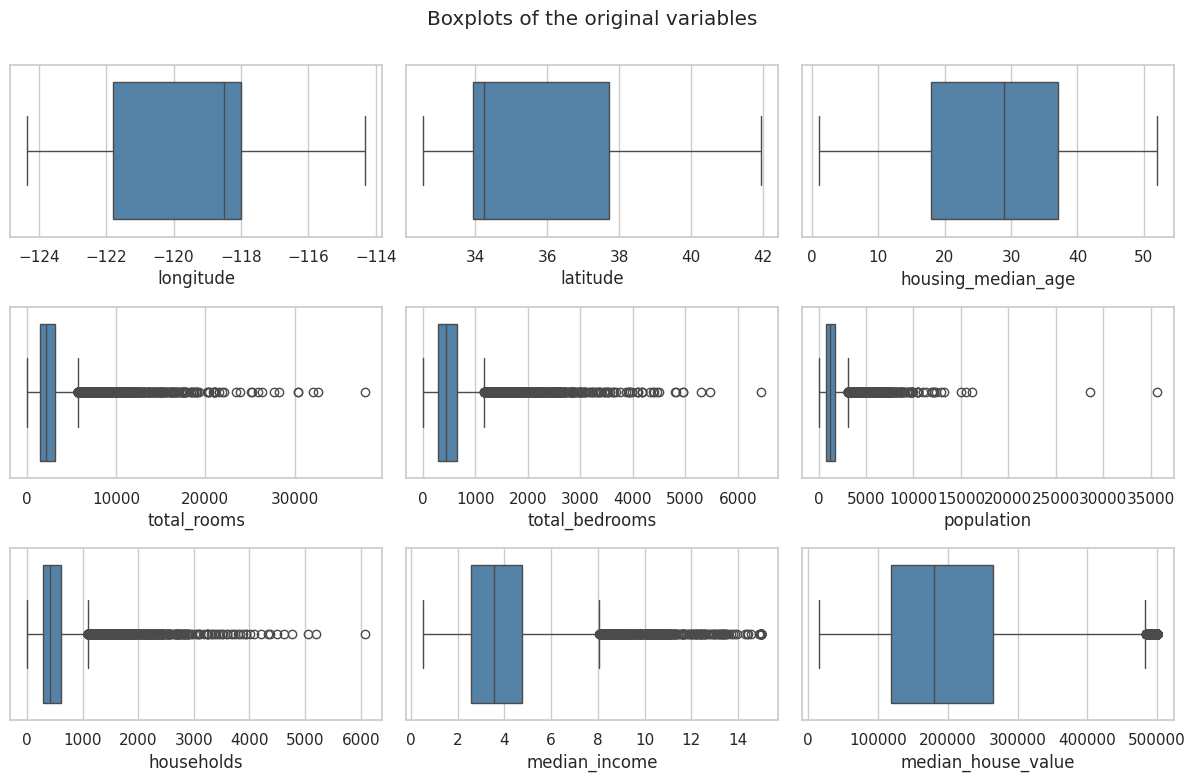

In [164]:
plot_boxplots(housing_df, ALL_COLUMNS)

In [165]:
def clean_housing_data(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    """
    Drop duplicated rows, rows with missing values and rows whose target is at
    the price cap.

    Returns the cleaned frame and a dictionary with the number of rows affected
    by each step.
    """

    summary = {"initial_rows": len(df)}

    deduplicated = df.drop_duplicates()
    summary["duplicates_removed"] = len(df) - len(deduplicated)

    complete = deduplicated.dropna(subset=ALL_COLUMNS)
    summary["rows_with_nulls_removed"] = len(deduplicated) - len(complete)

    price_cap = float(df[TARGET].max())
    uncapped = complete[complete[TARGET] < price_cap]
    summary["capped_target_removed"] = len(complete) - len(uncapped)

    summary["final_rows"] = len(uncapped)
    return uncapped.reset_index(drop=True), summary

In [166]:
clean_df, cleaning_summary = clean_housing_data(housing_df)
pd.Series(cleaning_summary, name="rows")

,rows
initial_rows,17000
duplicates_removed,0
rows_with_nulls_removed,0
capped_target_removed,814
final_rows,16186


## 4.0 Exploratory Graphs

In [167]:
def plot_target_distribution(df: pd.DataFrame) -> None:
    """
    Histogram of the target, marking the maximum value (the price cap).
    """

    price_cap = float(df[TARGET].max())
    plt.figure(figsize=(8, 4))
    sns.histplot(df[TARGET], bins=50)
    plt.axvline(price_cap, color="crimson", linestyle="--", label=f"maximum = {price_cap:,.0f}")

    plt.title("Distribution of median_house_value")
    plt.legend()

    plt.tight_layout()
    plt.show()

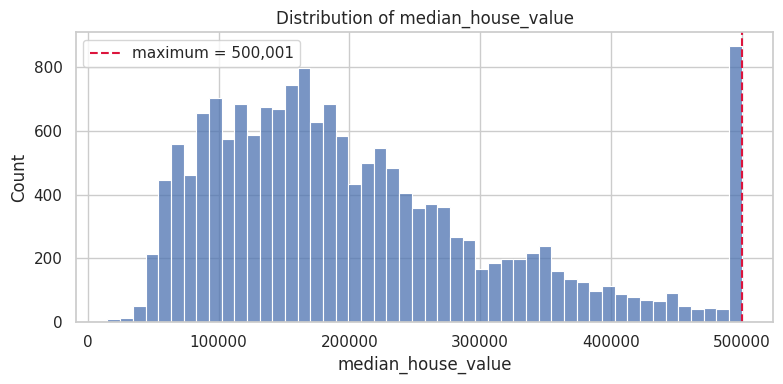

In [168]:
plot_target_distribution(housing_df)

In [169]:
def plot_price_map(df: pd.DataFrame) -> None:
    """
    Scatter plot of longitude vs latitude coloured by house value.
    """

    plt.figure(figsize=(7, 6))
    points = plt.scatter(df["longitude"], df["latitude"], c=df[TARGET], s=6, cmap="viridis", alpha=0.6)
    plt.colorbar(points, label=TARGET)

    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title("House value by location")

    plt.tight_layout()
    plt.show()


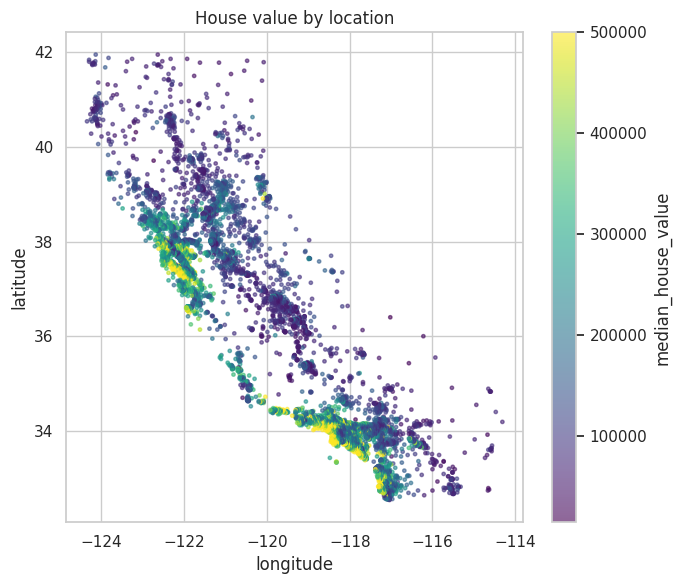

In [170]:
plot_price_map(housing_df)

## 5.0 Exercise 1: Variable Transformations

In [171]:
def yeo_johnson(series: pd.Series) -> np.ndarray:
    """
    Yeo-Johnson transformation of one column, returned as a flat array.

    power_transform standardizes its output (mean 0, std 1) by default.
    """

    values = series.to_numpy(dtype=float).reshape(-1, 1)
    return power_transform(values, method="yeo-johnson").ravel()

In [172]:
def transform_columns(df: pd.DataFrame, columns: list[str]) -> dict[str, np.ndarray]:
    """
    Apply yeo_johnson to each column and keep the results in a dictionary.
    """

    return {col: yeo_johnson(df[col]) for col in columns}

In [173]:
yeo_johnson_arrays = transform_columns(housing_df, ALL_COLUMNS)

In [174]:
def plot_original_vs_transformed(df: pd.DataFrame, transformed: dict[str, np.ndarray]) -> None:
    """
    Histograms of each variable: original (left) and Yeo-Johnson (right).
    """

    n_rows = len(transformed)
    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 2.2 * n_rows))
    for row, (col, values) in enumerate(transformed.items()):
        axes[row, 0].hist(df[col], bins=30)
        axes[row, 0].set_ylabel(col)
        axes[row, 1].hist(values, bins=30)

    axes[0, 0].set_title("Original")
    axes[0, 1].set_title("Yeo-Johnson")

    fig.tight_layout()
    plt.show()

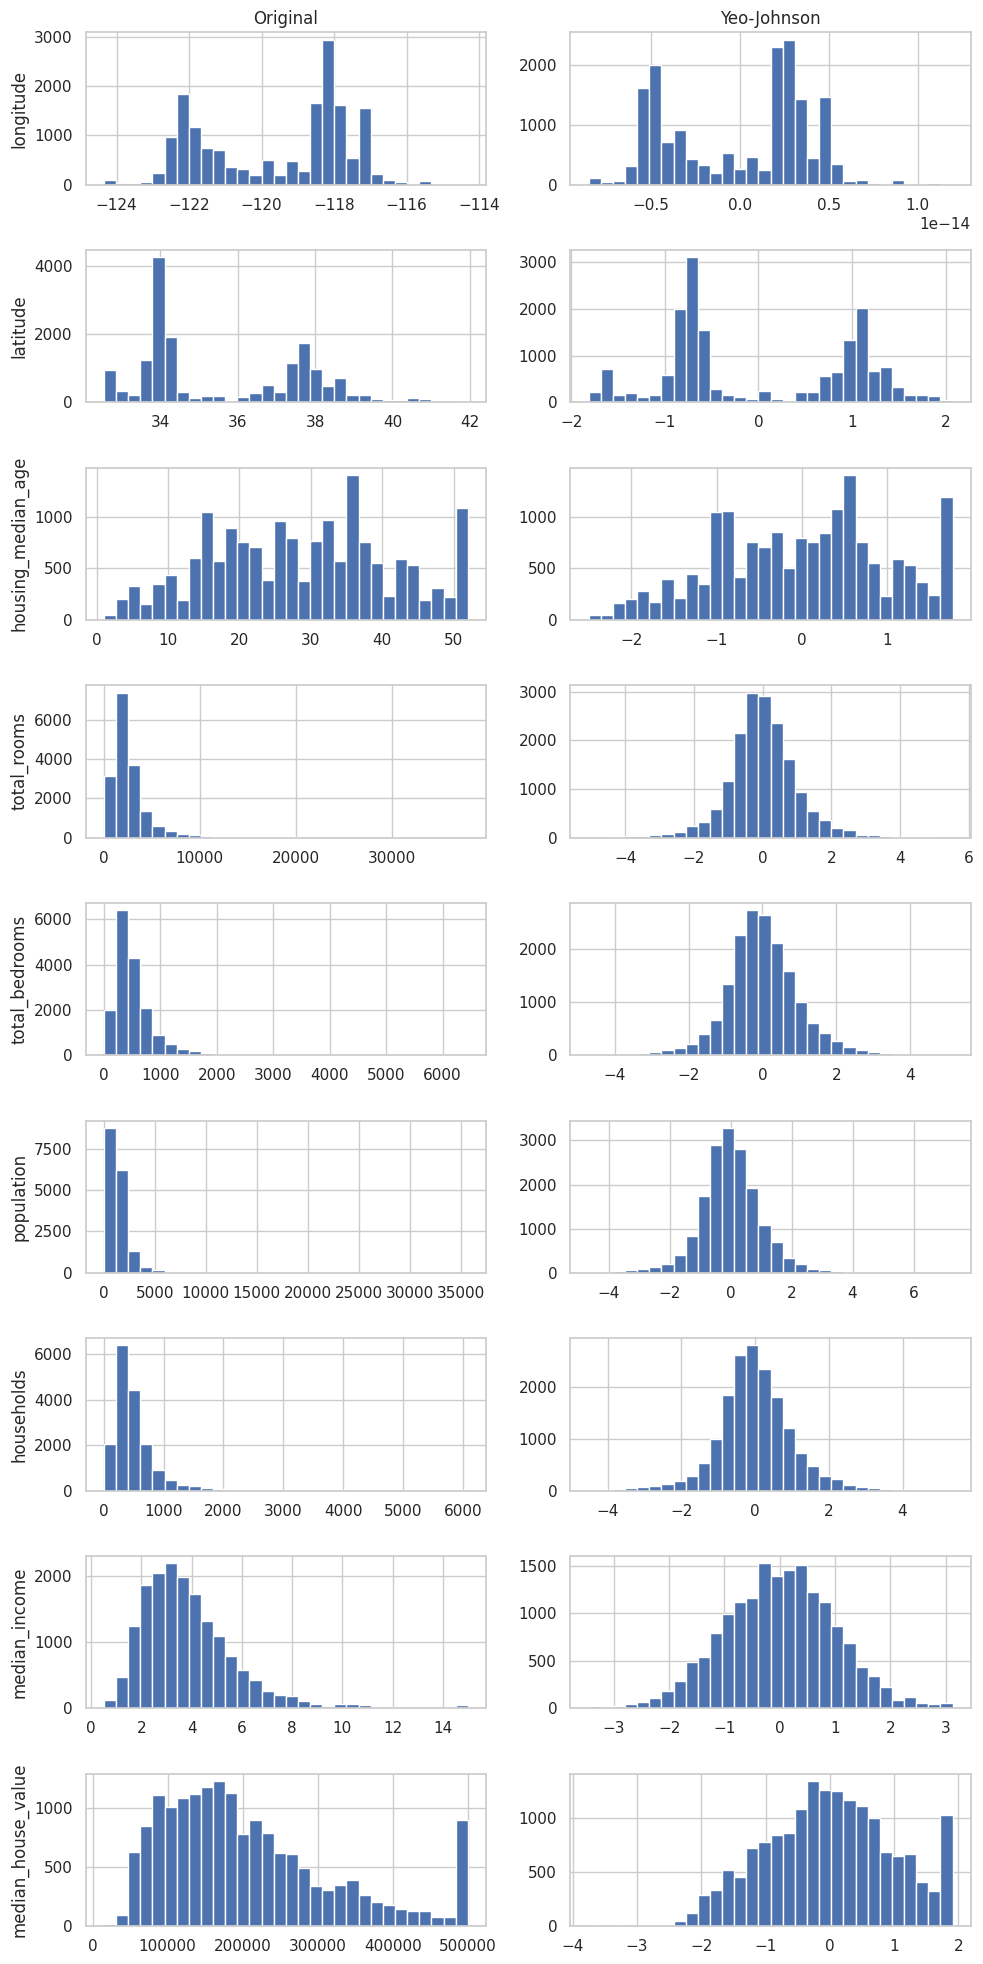

In [175]:
plot_original_vs_transformed(housing_df, yeo_johnson_arrays)

Las variables `total_rooms`, `total_bedrooms`, `population` y `households` tienen un sesgo positivo claro. `median_income` y la variable de salida `median_house_value` tienen un sesgo un poco menor.

In [176]:
def skewness_table(df: pd.DataFrame, transformed: dict[str, np.ndarray]) -> pd.DataFrame:
    """S
    kewness of each variable before and after Yeo-Johnson.
    """

    return pd.DataFrame({
        "variable": list(transformed),
        "original": [float(df[col].skew()) for col in transformed],
        "yeo_johnson": [float(pd.Series(values).skew()) for values in transformed.values()],
    }).round(3)


In [177]:
def plot_skewness(table: pd.DataFrame) -> None:
    """
    Grouped horizontal bars comparing skewness before and after the transformation.
    """

    long_table = table.melt(id_vars="variable", var_name="version", value_name="skewness")
    plt.figure(figsize=(9, 5))
    sns.barplot(data=long_table, x="skewness", y="variable", hue="version")

    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Skewness before and after Yeo-Johnson")

    plt.tight_layout()
    plt.show()

In [178]:
skew_table = skewness_table(housing_df, yeo_johnson_arrays)
skew_table

,variable,original,yeo_johnson
0,longitude,-0.304,0.000
1,latitude,0.472,0.156
2,housing_median_age,0.065,-0.113
3,total_rooms,4.003,0.114
4,total_bedrooms,3.323,0.098
5,population,5.187,0.105
6,households,3.343,0.103
7,median_income,1.627,-0.002
8,median_house_value,0.973,-0.013


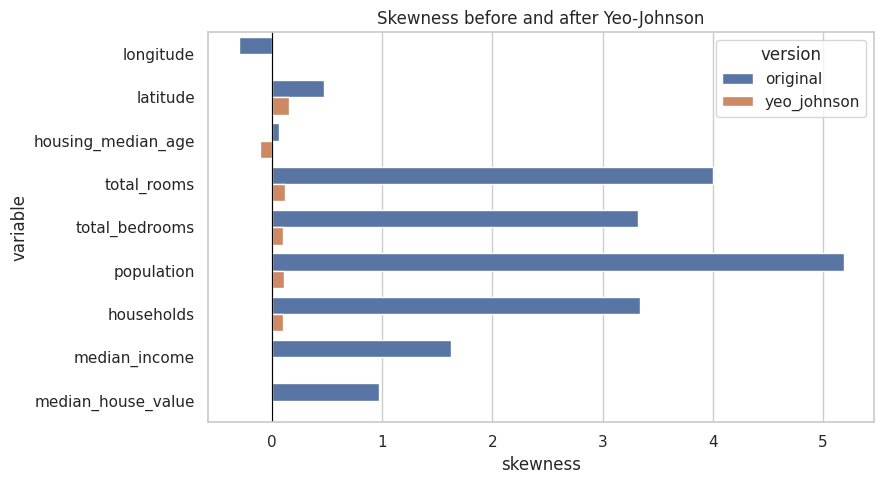

In [179]:
plot_skewness(skew_table)

### Evidence for Answer 1.4 (scaling and plain linear regression)

In [180]:
def scaling_invariance_check(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fit OLS on raw and standardized inputs: same R^2, different coefficient sizes.
    """

    complete = df.dropna(subset=ALL_COLUMNS)
    inputs, target = complete[FEATURES], complete[TARGET]
    inputs_std = StandardScaler().fit_transform(inputs)
    model_raw = LinearRegression().fit(inputs, target)
    model_std = LinearRegression().fit(inputs_std, target)

    return pd.DataFrame({
        "R2_raw_inputs": [model_raw.score(inputs, target)],
        "R2_standardized_inputs": [model_std.score(inputs_std, target)],
        "largest_abs_coef_raw": [float(np.abs(model_raw.coef_).max())],
        "largest_abs_coef_standardized": [float(np.abs(model_std.coef_).max())],
    }).round(6)

In [181]:
scaling_invariance_check(housing_df)

,R2_raw_inputs,R2_standardized_inputs,largest_abs_coef_raw,largest_abs_coef_standardized
0,0.641338,0.641338,43139.637258,91744.050831


#### Evidence for Answer 1.5 (Yeo-Johnson already standardizes)

In [182]:
def standardization_check(transformed: dict[str, np.ndarray]) -> pd.DataFrame:
    """
    Mean and standard deviation of each variable after Yeo-Johnson.
    """

    return pd.DataFrame({
        "variable": list(transformed),
        "mean": [float(values.mean()) for values in transformed.values()],
        "std": [float(values.std()) for values in transformed.values()],
    }).round(4)

In [183]:
standardization_check(yeo_johnson_arrays)

,variable,mean,std
0,longitude,0.0,0.0
1,latitude,0.0,1.0
2,housing_median_age,-0.0,1.0
3,total_rooms,-0.0,1.0
4,total_bedrooms,-0.0,1.0
5,population,0.0,1.0
6,households,-0.0,1.0
7,median_income,0.0,1.0
8,median_house_value,0.0,1.0


#### Evidence for Answer 1.6 (order of the transformations)

In [184]:
def order_comparison(series: pd.Series) -> dict[str, float]:
    """
    Compare Yeo-Johnson -> scale against scale -> Yeo-Johnson on one variable.
    """

    values = series.dropna().to_numpy(dtype=float).reshape(-1, 1)
    yj_then_scale = StandardScaler().fit_transform(power_transform(values, method="yeo-johnson"))
    scale_then_yj = power_transform(StandardScaler().fit_transform(values), method="yeo-johnson")

    return {
        "max_abs_difference": float(np.abs(yj_then_scale - scale_then_yj).max()),
        "skew_yj_then_scale": float(pd.Series(yj_then_scale.ravel()).skew()),
        "skew_scale_then_yj": float(pd.Series(scale_then_yj.ravel()).skew()),
    }

In [185]:
pd.DataFrame({col: order_comparison(housing_df[col]) for col in ["total_rooms", "population"]}).T.round(4)

,max_abs_difference,skew_yj_then_scale,skew_scale_then_yj
total_rooms,2.3858,0.1136,-0.0020
population,3.0791,0.1050,0.0071


#### Evidence for Answer 1.9 (the price cap)

In [186]:
def cap_stats(df: pd.DataFrame, column: str = TARGET) -> tuple[float, int, float]:
    """
    Maximum of a column, number of rows at that value and their percentage.
    """

    cap = float(df[column].max())
    n_cap = int((df[column] == cap).sum())

    return cap, n_cap, 100 * n_cap / len(df)

In [187]:
cap, n_cap, pct_cap = cap_stats(housing_df)
print(f"Maximum {TARGET}: {cap:,.0f} | rows at that value: {n_cap} ({pct_cap:.2f}%)")

Maximum median_house_value: 500,001 | rows at that value: 814 (4.79%)


### Exercise 1: Answers

Teniendo en cuenta que se analizan los datos para aplicar después una regresión lineal múltiple.

**Pregunta 1.1.** ¿Para qué se aplica usualmente la transformación Yeo-Johnson y cuál es su diferencia con Box-Cox?

**Respuesta 1.1.**
Yeo-Johnson se usa para arreglar el sesgo de una variable, o sea, para que sus datos queden más parejos y parecidos a una normal. Lo hace con una potencia cuyo valor (lambda) se calcula solo a partir de los datos. La diferencia con Box-Cox es que Box-Cox solo funciona con valores positivos, y Yeo-Johnson también acepta ceros y negativos. Por eso es más general.

**Pregunta 1.2.** ¿Cuál es la diferencia entre utilizar la métrica de la raíz cuadrada del error cuadrático medio RMSE (Root Mean Squared Error) y la del error absoluto medio MAE (Mean Absolute Error)? ¿Cuándo se recomienda utilizar cada uno?

**Respuesta 1.2.**
Las dos miden qué tanto se equivoca el modelo, en las mismas unidades que la variable de salida. El RMSE eleva los errores al cuadrado, así que castiga mucho más los errores grandes y le afectan los valores atípicos. El MAE solo promedia los errores en valor absoluto, entonces es más fácil de interpretar y aguanta mejor los atípicos. Usaría RMSE cuando un error grande sea muy costoso, y MAE cuando haya atípicos o cuando todos los errores importen igual.

**Pregunta 1.3.** Si vamos a aplicar posteriormente el modelo de regresión lineal múltiple y habiendo observado de los histogramas que las variables de entrada total_rooms, total_bedrooms, population, households y median_income tienen sesgos positivos ¿es recomendable aplicar alguna transformación de corrección de sesgo, como la mostrada de Yeo-Johnson en dichas variables? ¿Por qué?

**Respuesta 1.3.**
Sí me parece recomendable. La regresión lineal no necesita que las variables de entrada sean normales, eso se pide más bien a los residuos. Pero variables como total_rooms, total_bedrooms, population y households tienen unos cuantos valores enormes que pesan demasiado en el ajuste y pueden hacer que la relación con la salida no sea lineal. Con Yeo-Johnson esos valores extremos pesan menos. En median_income el sesgo es menor, así que ayudaría menos. Lo mejor sería probar el modelo con y sin la transformación y comparar el error. Lo malo es que los coeficientes ya no quedan en las unidades originales.

**Pregunta 1.4.** Considerando ahora todas las variables de entrada de este problema, ¿es recomendable aplicarles alguna transformación de ajuste de escala (por ejemplo, la min-max, o la de normalización) antes de aplicar el modelo de regresión lineal múltiple? ¿Por qué?

**Respuesta 1.4.**
Sí, aunque para una regresión lineal normal no es obligatorio, porque las predicciones salen igual con o sin escalar. Yo lo haría de todos modos porque las variables tienen escalas muy distintas (longitude anda en -120 y total_rooms en miles). Al escalar se pueden comparar los coeficientes y el cálculo numérico es más estable. Si después se usa regularización (Ridge o Lasso) o gradiente, ya sí es necesario. Usaría estandarización y ajustaría el escalador solo con los datos de entrenamiento.

**Pregunta 1.5.** Supongamos que ya decidiste aplicar la transformación Yeo-Johnson a las variables sesgadas identificadas previamente. Una vez aplicada la Yeo-Johnson, ¿también es válido o recomendable aplicarles ahora una transformación de escala? ¿Por qué? En particular, observa los histogramas resultantes con Yeo-Johnson obtenidos anteriormente para respaldar tu respuesta.

**Respuesta 1.5.**
No hace falta. power_transform ya estandariza por defecto (standardize=True), y la tabla de comprobación lo confirma: las variables sesgadas quedan con media 0 y desviación 1. Se nota también en los histogramas, donde los ejes van más o menos de -3 a 3, mientras que en los originales hay valores de cientos o miles. Volver a estandarizar no cambiaría nada, y un min-max sería válido pero repetido. La única rara es longitude, que salió con desviación 0 (quedó casi constante), lo cual confirma que Yeo-Johnson no le sirve.

**Pregunta 1.6.** Supongamos que por alguna razón ya decidiste aplicar a las variables sesgadas tanto la transformación Yeo-Johnson como la transformación de escala, ¿sería lo mismo aplicar primero la Yeo-Johnson seguida de la transformación de escala, que si lo hiciéramos al revés, es decir, primero la transformación de escala y luego la Yeo-Johnson? Justifica tu respuesta.

**Respuesta 1.6.**
No es lo mismo. Yeo-Johnson no es lineal, así que su resultado depende de dónde están los datos y de qué tan grandes son, y por eso escalar antes lo cambia. En la celda de evidencia se ve: las dos formas de hacerlo dan valores distintos (la diferencia máxima entre ellas es de 2.4 desviaciones en total_rooms y 3.1 en population). Curiosamente, en estos datos escalar primero dejó el sesgo un poco más cerca de cero (casi 0 contra 0.11), pero eso no las vuelve equivalentes: cambia el lambda que se calcula y con eso la forma final. Yo prefiero primero Yeo-Johnson y después escalar, que es el orden más común, y como Yeo-Johnson ya estandariza, el escalamiento aparte casi sobra.

**Pregunta 1.7.** Observa ahora los histogramas de las variables de entrada originales "longitude" y "latitude". Claramente podríamos considerar a dichos histogramas como gráficos bimodales. ¿Qué se recomienda hacer en este caso? Es decir, ¿qué tipo de transformación o transformaciones se recomiendan aplicar? En particular, en este caso se observa que para estas variables la Yeo-Johnson no ayudó en absoluto.

**Respuesta 1.7.**
Longitude y latitude tienen dos picos porque son coordenadas y las casas se juntan en pocas zonas, como la Bahía de San Francisco y la zona de Los Ángeles y San Diego. Yeo-Johnson no ayuda porque arregla el sesgo, no los dos picos: en mis resultados longitude quedó casi constante (desviación 0) y latitude siguió con sus dos picos. Yo las trataría como ubicación y no como números normales. Se pueden agrupar las coordenadas con K-means y volver esa zona una variable categórica con one-hot, dividir el mapa en una cuadrícula, o crear variables como la distancia a las ciudades grandes o a la costa. También se puede usar un modelo no lineal.

**Pregunta 1.8.** Analicemos ahora la variable de salida median_house_value. ¿Cuál es ahora la recomendación para ajustar o transformar el sesgo o de corrección de escala? ¿Serían exactamente las mismas recomendaciones que se hicieron para las variables de entrada o se aplicaría un criterio diferente? Justifica tu respuesta.

**Respuesta 1.8.**
Aquí el criterio es distinto. En la salida no se busca normalizar una entrada, sino que los errores del modelo sean más parejos, porque con precios el error suele crecer cuando sube el precio. Un logaritmo o Yeo-Johnson pueden ayudar, pero hay que regresar las predicciones a dólares y calcular RMSE y MAE en esa escala para poder interpretarlos. Escalar la salida no hace falta en la regresión lineal, solo cambia las unidades. En scikit-learn se puede hacer con TransformedTargetRegressor.

**Pregunta 1.9.** Observa ahora el histograma de la variable de salida "median_house_value", ya sea la original o la transformada. Claramente se observa un "pico" al final de cualquiera de estos histogramas. ¿Qué transformación, criterio o recomendación adicional aplicaría para este tipo de gráficos?

**Respuesta 1.9.**
El pico del final se debe a que los precios están topados: todas las casas que cuestan más de cierto valor quedaron con el mismo valor máximo, 500,001. En estos datos son 814 registros, el 4.79%. Ninguna transformación lo arregla. Lo que se puede hacer es quitar esos registros del entrenamiento, o tratarlos como datos censurados con un modelo hecho para eso (como Tobit), o por lo menos agregar una variable que marque cuáles están topados. Si se dejan así, el modelo aprende que las casas más caras valen solo el tope y la recta se baja. Si se quitan, hay que aclarar que el modelo no sirve para precios arriba de ese límite. Algo parecido pasa con housing_median_age, que también tiene un tope en 52.

## Exercise 2: Pearson Correlation Matrix

In [188]:
def build_yj_frame(df: pd.DataFrame) -> pd.DataFrame:
    """
    Copy of the data where the skewed columns are Yeo-Johnson transformed (suffix _yj).
    """

    out = pd.DataFrame(index=df.index)
    for col in ALL_COLUMNS:
        if col in YJ_COLUMNS:
            out[col + YJ_SUFFIX] = yeo_johnson(df[col])
        else:
            out[col] = df[col]

    return out

In [189]:
def plot_correlation_heatmap(corr: pd.DataFrame, title: str) -> None:
    """
    Annotated heatmap of a correlation matrix.
    """

    plt.figure(figsize=(9, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="BuGn")

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [190]:
yj_frame = build_yj_frame(housing_df)
correlation_matrix = yj_frame.corr(method="pearson")

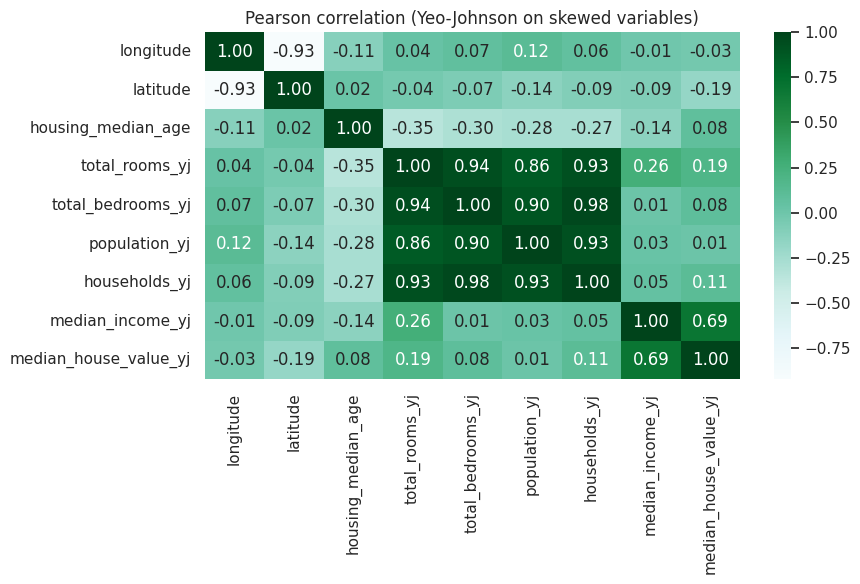

In [191]:
plot_correlation_heatmap(correlation_matrix, "Pearson correlation (Yeo-Johnson on skewed variables)")

### Correlation with the target, before and after cleaning

In [192]:
def target_correlations(corr: pd.DataFrame, target: str) -> pd.Series:
    """
    Correlation of every other variable with the target, sorted from highest to lowest.
    """

    return corr[target].drop(target).sort_values(ascending=False)

In [193]:
def compare_target_correlations(raw_corr: pd.DataFrame, clean_corr: pd.DataFrame, target: str) -> pd.DataFrame:
    """
    Side-by-side correlations with the target for the raw and the cleaned data.
    """

    return pd.DataFrame({
        "raw_data": target_correlations(raw_corr, target),
        "cleaned_data": target_correlations(clean_corr, target),
    }).round(3)

In [194]:
clean_correlation_matrix = build_yj_frame(clean_df).corr(method="pearson")
correlation_comparison = compare_target_correlations(
    correlation_matrix, clean_correlation_matrix, TARGET_YJ
)

correlation_comparison

,raw_data,cleaned_data
median_income_yj,0.685,0.655
total_rooms_yj,0.187,0.193
households_yj,0.108,0.136
total_bedrooms_yj,0.083,0.108
housing_median_age,0.082,0.051
population_yj,0.013,0.049
longitude,-0.026,-0.024
latitude,-0.188,-0.188


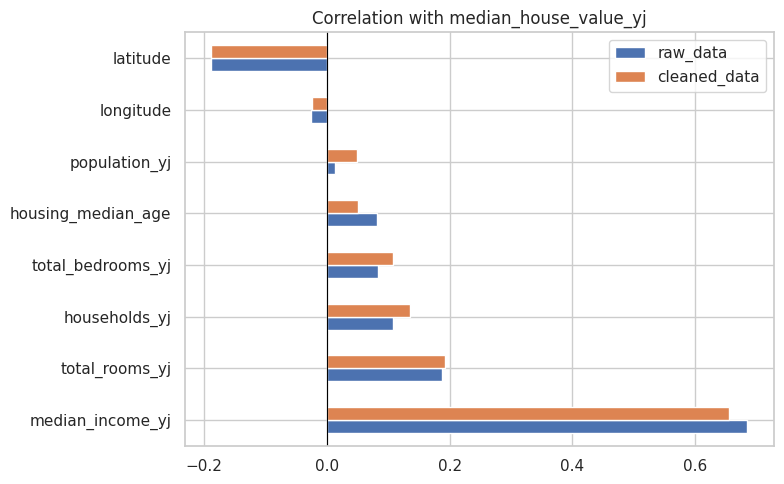

In [195]:
correlation_comparison.plot(kind="barh", figsize=(8, 5), title="Correlation with median_house_value_yj")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Multicollinearity among the inputs

In [196]:
def high_corr_pairs(corr: pd.DataFrame, target: str, threshold: float = 0.7) -> pd.DataFrame:
    """
    Input pairs whose absolute correlation is above the threshold.
    """

    inputs = corr.drop(index=target, columns=target)
    upper = inputs.where(np.triu(np.ones(inputs.shape, dtype=bool), k=1)).stack().reset_index()
    upper.columns = ["variable_1", "variable_2", "correlation"]
    keep = upper[upper["correlation"].abs() > threshold]

    return keep.sort_values("correlation", key=abs, ascending=False).round(3)

In [197]:
def variance_inflation(corr: pd.DataFrame, target: str) -> pd.Series:
    """
    VIF of each input: diagonal of the inverse of the inputs' correlation matrix.
    """

    inputs = corr.drop(index=target, columns=target)
    return pd.Series(np.diag(np.linalg.inv(inputs.to_numpy())), index=inputs.columns).round(2)

In [198]:
def plot_vif(vif: pd.Series, threshold: float = 5.0) -> None:
    """
    Horizontal bars of the VIF of each input with a reference line.
    """

    plt.figure(figsize=(8, 4))
    vif.sort_values().plot(kind="barh")
    plt.axvline(threshold, color="crimson", linestyle="--", label=f"VIF = {threshold:g}")

    plt.title("Variance inflation factor")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [199]:
high_corr_pairs(correlation_matrix, TARGET_YJ)

,variable_1,variable_2,correlation
23,total_bedrooms_yj,households_yj,0.977
18,total_rooms_yj,total_bedrooms_yj,0.939
25,population_yj,households_yj,0.929
20,total_rooms_yj,households_yj,0.928
0,longitude,latitude,-0.925
22,total_bedrooms_yj,population_yj,0.897
19,total_rooms_yj,population_yj,0.862


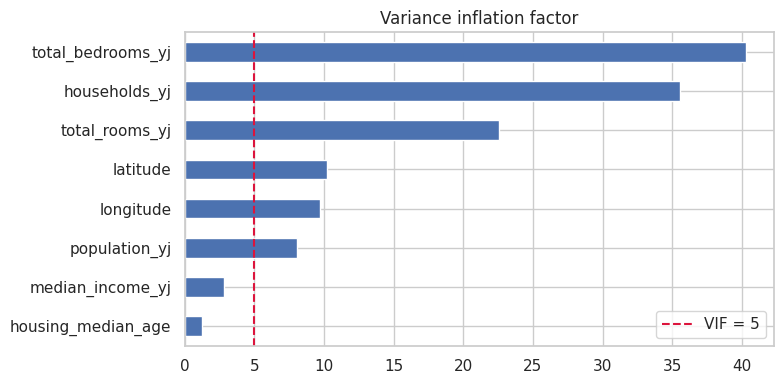

In [200]:
vif_values = variance_inflation(correlation_matrix, TARGET_YJ)
plot_vif(vif_values)

### Exercise 2 Answers

**Pregunta 2.1.** ¿A qué tipo de variables (numéricas o categóricas) se aplica la matriz de correlación Pearson? ¿Y cuál es el objetivo de obtener dicha matriz?

**Respuesta 2.1.**
Se aplica a variables numéricas, no a categóricas. Mide qué tan fuerte es la relación lineal entre dos variables, con valores de -1 a 1. Sirve para ver qué variables de entrada se relacionan más con la salida y para encontrar variables de entrada que se parecen demasiado entre sí (multicolinealidad). Hay que tener en cuenta que le afectan los valores atípicos y que no detecta relaciones que no sean lineales.

**Pregunta 2.2.** Con respecto a la variable de salida, ¿qué variables de entrada están mayormente correlacionadas con ella? ¿Tiene sentido dentro del contexto y significado de las variables del problema?

**Respuesta 2.2.**
La que más se correlaciona con la salida es median_income_yj, con 0.685, y por bastante diferencia: la siguiente es total_rooms_yj con 0.187. Tiene sentido: donde el ingreso de las familias es más alto, las casas suelen costar más.

**Pregunta 2.3.** En particular ¿cómo explicas el valor de correlación obtenido del factor "longitude" con respecto a la variable de salida transformada?

**Respuesta 2.3.**
La correlación de longitude con la salida es casi cero (-0.026). Eso no significa que no sirva, sino que la relación no es lineal: las zonas caras están en la costa, tanto en San Francisco (longitud cerca de -122) como en Los Ángeles (cerca de -118), y el interior es más barato. Pearson solo ve relaciones lineales, por eso da casi cero. Además, longitude y latitude están muy correlacionadas entre sí (-0.925) porque la costa de California va en diagonal.

**Pregunta 2.4.** ¿Y cómo explicas el valor de correlación obtenido del factor "latitude" con respecto a la variable de salida transformada? ¿Tiene sentido con respecto al significado del problema?

**Respuesta 2.4.**
Con latitude la correlación es baja y negativa (-0.188), un poco mayor que la de longitude. Tiene sentido con el problema, porque los precios altos se concentran en zonas específicas (San Francisco, cerca de 37.7°, y Los Ángeles y San Diego, entre 32° y 34°), y el Valle Central y el norte son más baratos. La relación tampoco es lineal. La variable sí trae información de ubicación, pero habría que transformarla (agrupar, cuadrícula o distancia a ciudades) para aprovecharla.

**Pregunta 2.5.** Observa que con respecto a las variables de entrada y el concepto de multicolinealidad, varias de ellas tienen un alto valor de correlación de Pearson, ¿qué decisiones podemos tomar ahora con respecto a dichas variables?

**Respuesta 2.5.**
Varias variables de entrada están muy correlacionadas entre sí: total_bedrooms con households (0.977), total_rooms con total_bedrooms (0.939) y population con households (0.929), además de longitude con latitude (-0.925). Eso es multicolinealidad: repiten casi la misma información y hacen que los coeficientes sean inestables y difíciles de interpretar, aunque casi no afecta las predicciones. Se puede quitar las que sobran y dejar una, crear variables combinadas como habitaciones por hogar, dormitorios por habitación o población por hogar, usar PCA, o usar regularización (Ridge, Lasso o ElasticNet). El VIF de las celdas de arriba sirve para ver qué tan grave es.

## Exercise 3: Conclusiones Finales

Con esta actividad entendí que preparar los datos no es aplicar transformaciones en automático, sino decidir qué necesita cada variable y para qué modelo. Lo que más me quedó claro fue lo de Yeo-Johnson: corrige el sesgo, pero además ya deja las variables estandarizadas, así que escalar otra vez no aporta nada, y el orden en que se aplican las dos cosas sí cambia el resultado. También vi que hay problemas que ninguna transformación arregla. El pico en `median_house_value` viene de un tope en los precios (500,001), y eso se resuelve quitando esos registros o tratándolos como datos censurados. De hecho, en los datos son 814 registros (casi 5%), y al quitarlos la correlación entre `median_income` y el precio baja de 0.685 a 0.655, lo que muestra cuánto distorsiona ese tope los datos originales. Con `longitude` y `latitude` pasa algo parecido: casi no se correlacionan con el precio, pero no es porque no importen, sino porque la relación con la ubicación no es lineal y Pearson solo detecta relaciones lineales. Y con `total_rooms`, `total_bedrooms`, `population` y `households` aprendí sobre la multicolinealidad: repiten casi la misma información (por ejemplo, `total_bedrooms` y `households` tienen una correlación de 0.977), así que hay que decidir si se quitan, se combinan o se regularizan. Por último, las gráficas y la limpieza de datos me ayudaron a ver cosas que en la tabla no se notaban, como el tope de precios y los valores atípicos.

Para hacer la actividad usé Claude como apoyo, y lo usé de ida y vuelta, no para pedir una sola respuesta. Fui platicando con él las ideas, agregando gráficas y la limpieza de los datos. Después de cada versión revisé lo que me daba y le fui pidiendo ajustes. También le pedí que revisara el código: probó el cuaderno con datos sintéticos (datos inventados con duplicados y valores faltantes) para comprobar que todas las celdas corrieran sin errores, y después comparó los resultados que yo obtuve en Colab con mis respuestas, con lo que detectamos y corregimos varias que no coincidían (por ejemplo, el orden de las transformaciones y el caso de longitude). Lo más útil fue tener con quién discutir cada respuesta, porque para decidir si la aceptaba o la cambiaba tenía que entender el porqué.

## References

Anthropic. (2026). *Claude* (versión Claude Sonnet 5.5) [Modelo de lenguaje de gran tamaño]. https://claude.ai